# Decay Timing Analysis
Correlates stable-phase metrics with probe decay final validation loss.

In [10]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

In [11]:
# Point this to your run directory
LOG_DIR = Path("../logs")  # adjust if running from a different location

# List available runs
runs = sorted(LOG_DIR.iterdir())
for i, r in enumerate(runs):
    has_sweep = (r / "decay_sweep.jsonl").exists()
    print(f"{i:2d}  {r.name}  {'[sweep]' if has_sweep else ''}")

 0  cosine_0_1b_fineweb_2_6b_20260604-085109  
 1  cosine_debug_20260604-080734  
 2  cosine_intermediate_paper_decay_20260605-154448  
 3  wsd_debug_20260604-080859  
 4  wsd_intermediate_amount_sweep_20260605-154506  
 5  wsd_intermediate_fineweb_0_5b_20260604-140516  
 6  wsd_intermediate_paper_decay_20260605-154459  
 7  wsd_intermediate_sweep_r003_20260604-094651  [sweep]
 8  wsd_intermediate_sweep_r003_20260604-112221  [sweep]
 9  wsd_intermediate_sweep_r010_20260604-140648  [sweep]
10  wsd_s_0_1b_fineweb_2_6b_20260604-104941  


In [12]:
# Select a run
RUN_NAME = "wsd_intermediate_amount_sweep_20260605-154506"
RUN = LOG_DIR / RUN_NAME
assert RUN.exists(), f"Missing run directory: {RUN}"
assert (RUN / "decay_amount_sweep.jsonl").exists(), f"Missing decay sweep: {RUN}"
print("Using:", RUN.name)

def read_jsonl(path):
    with open(path) as f:
        return pd.DataFrame(json.loads(line) for line in f)

metrics = read_jsonl(RUN / "metrics.jsonl")
sweep   = read_jsonl(RUN / "decay_amount_sweep.jsonl")

val_rows = metrics[metrics["validation_loss"].notna()][["step", "validation_loss"]].copy()
val_rows = val_rows.rename(columns={"step": "probe_start_step", "validation_loss": "probe_start_val_loss"})
sweep = sweep.merge(val_rows, on="probe_start_step", how="left")
assert sweep["probe_start_val_loss"].notna().all(), "Missing validation loss for at least one probe start"

print(f"metrics rows: {len(metrics)}, sweep rows: {len(sweep)}")
sweep.head()

Using: wsd_intermediate_amount_sweep_20260605-154506
metrics rows: 360, sweep rows: 9


,probe_start_step,train_loss,loss_variance,loss_oscillation,loss_improvement_rate,grad_norm,grad_snr,grad_weight_ratio,grad_cosine_sim,adam_v_norm,weight_norm,param_update_norm,learning_rate,decay_length,final_lr_ratio,probe_final_val_loss,probe_start_val_loss
0,900,4.260197,0.178898,0.032907,-0.000892,0.284775,1.160229,0.000966,-0.117399,0.000232,294.675323,1.06055,0.0006,100,0.50,4.134357,4.223833
1,900,4.260197,0.178898,0.032907,-0.000892,0.284775,1.160229,0.000966,-0.117399,0.000232,294.675323,1.06055,0.0006,100,0.30,4.128516,4.223833
2,900,4.260197,0.178898,0.032907,-0.000892,0.284775,1.160229,0.000966,-0.117399,0.000232,294.675323,1.06055,0.0006,100,0.20,4.128592,4.223833
3,900,4.260197,0.178898,0.032907,-0.000892,0.284775,1.160229,0.000966,-0.117399,0.000232,294.675323,1.06055,0.0006,100,0.10,4.134906,4.223833
4,900,4.260197,0.178898,0.032907,-0.000892,0.284775,1.160229,0.000966,-0.117399,0.000232,294.675323,1.06055,0.0006,100,0.07,4.140264,4.223833


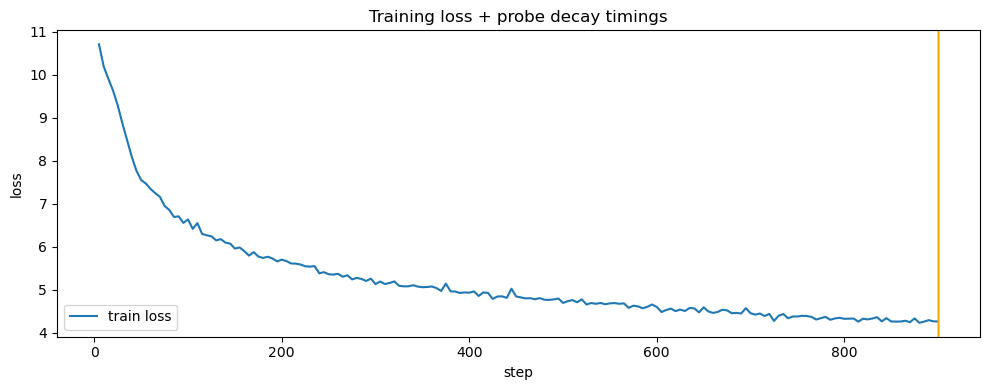

In [13]:
# Training loss curve with probe timing markers
train_rows = metrics[metrics["train_loss"].notna()]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_rows["step"], train_rows["train_loss"], label="train loss")
for step in sweep["probe_start_step"]:
    ax.axvline(step, color="orange", alpha=0.4, linewidth=1)
ax.set_xlabel("step")
ax.set_ylabel("loss")
ax.set_title("Training loss + probe decay timings")
ax.legend()
plt.tight_layout()
plt.show()

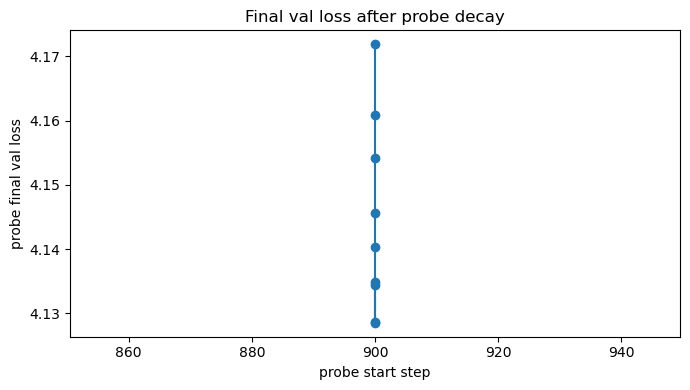

In [14]:
# Probe val loss vs decay start step
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sweep["probe_start_step"], sweep["probe_final_val_loss"], marker="o")
ax.set_xlabel("probe start step")
ax.set_ylabel("probe final val loss")
ax.set_title("Final val loss after probe decay")
plt.tight_layout()
plt.show()

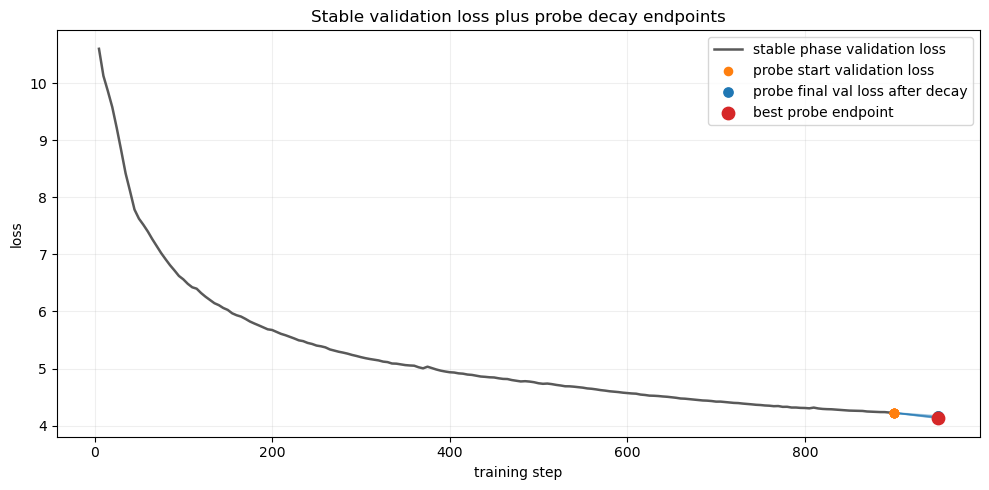

In [15]:
# Stable-phase validation loss with probe decay endpoints
# decay_sweep.jsonl stores only the final loss of each probe decay, not the full decay trajectory.
DECAY_LENGTH = 50  # from training.decay_sweep.decay_length in this run's config

val_curve = metrics[metrics["validation_loss"].notna()].copy()
sweep_plot = sweep.sort_values("probe_start_step").copy()
sweep_plot["probe_end_step"] = sweep_plot["probe_start_step"] + DECAY_LENGTH

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    val_curve["step"],
    val_curve["validation_loss"],
    color="0.35",
    linewidth=1.8,
    label="stable phase validation loss",
)

for _, row in sweep_plot.iterrows():
    ax.plot(
        [row["probe_start_step"], row["probe_end_step"]],
        [row["probe_start_val_loss"], row["probe_final_val_loss"]],
        color="tab:blue",
        alpha=0.25,
        linewidth=1.2,
    )

ax.scatter(
    sweep_plot["probe_start_step"],
    sweep_plot["probe_start_val_loss"],
    color="tab:orange",
    s=35,
    zorder=3,
    label="probe start validation loss",
)
ax.scatter(
    sweep_plot["probe_end_step"],
    sweep_plot["probe_final_val_loss"],
    color="tab:blue",
    s=45,
    zorder=4,
    label="probe final val loss after decay",
)

best = sweep_plot.loc[sweep_plot["probe_final_val_loss"].idxmin()]
ax.scatter(
    [best["probe_end_step"]],
    [best["probe_final_val_loss"]],
    color="tab:red",
    s=80,
    zorder=5,
    label="best probe endpoint",
)

ax.set_xlabel("training step")
ax.set_ylabel("loss")
ax.set_title("Stable validation loss plus probe decay endpoints")
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Correlation matrix: stable-phase metrics vs probe final validation loss
METRIC_COLS = [
    "probe_start_val_loss", "loss_variance", "loss_oscillation", "loss_improvement_rate",
    "grad_norm", "grad_snr", "grad_weight_ratio", "grad_cosine_sim",
    "adam_v_norm", "weight_norm", "param_update_norm",
]

# Keep only columns that exist
metric_cols = [c for c in METRIC_COLS if c in sweep.columns]
y = sweep["probe_final_val_loss"].values

rows = []
for col in metric_cols:
    x = sweep[col].values
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3:
        continue
    pearson_r, pearson_p = stats.pearsonr(x[mask], y[mask])
    spearman_r, spearman_p = stats.spearmanr(x[mask], y[mask])
    rows.append({
        "metric": col,
        "pearson_r": pearson_r, "pearson_p": pearson_p,
        "spearman_r": spearman_r, "spearman_p": spearman_p,
    })

corr_df = pd.DataFrame(rows).sort_values("pearson_r", key=abs, ascending=False)
corr_df.style.background_gradient(subset=["pearson_r", "spearman_r"], cmap="RdBu_r", vmin=-1, vmax=1)

/var/folders/vy/mf_w5k8s4rqbmvc9597rm_xr0000gn/T/ipykernel_25242/678976446.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_r, pearson_p = stats.pearsonr(x[mask], y[mask])
/var/folders/vy/mf_w5k8s4rqbmvc9597rm_xr0000gn/T/ipykernel_25242/678976446.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_r, spearman_p = stats.spearmanr(x[mask], y[mask])


,metric,pearson_r,pearson_p,spearman_r,spearman_p
0,probe_start_val_loss,nan,nan,nan,nan
1,loss_variance,nan,nan,nan,nan
2,loss_oscillation,nan,nan,nan,nan
3,loss_improvement_rate,nan,nan,nan,nan
4,grad_norm,nan,nan,nan,nan
5,grad_snr,nan,nan,nan,nan
6,grad_weight_ratio,nan,nan,nan,nan
7,grad_cosine_sim,nan,nan,nan,nan
8,adam_v_norm,nan,nan,nan,nan
9,weight_norm,nan,nan,nan,nan


/var/folders/vy/mf_w5k8s4rqbmvc9597rm_xr0000gn/T/ipykernel_25242/3983648833.py:14: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(x[mask], y[mask], 1)
/var/folders/vy/mf_w5k8s4rqbmvc9597rm_xr0000gn/T/ipykernel_25242/3983648833.py:14: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(x[mask], y[mask], 1)
/var/folders/vy/mf_w5k8s4rqbmvc9597rm_xr0000gn/T/ipykernel_25242/3983648833.py:14: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(x[mask], y[mask], 1)
/var/folders/vy/mf_w5k8s4rqbmvc9597rm_xr0000gn/T/ipykernel_25242/3983648833.py:14: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(x[mask], y[mask], 1)
/var/folders/vy/mf_w5k8s4rqbmvc9597rm_xr0000gn/T/ipykernel_25242/3983648833.py:14: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(x[mask], y[mask], 1)
/var/folders/vy/mf_w5k8s4rqbmvc9597rm_xr0000gn/T/ipykernel_25242/3983648833.py:14: RankWarning: Polyfit may be poorly conditioned
  m, b = np.pol

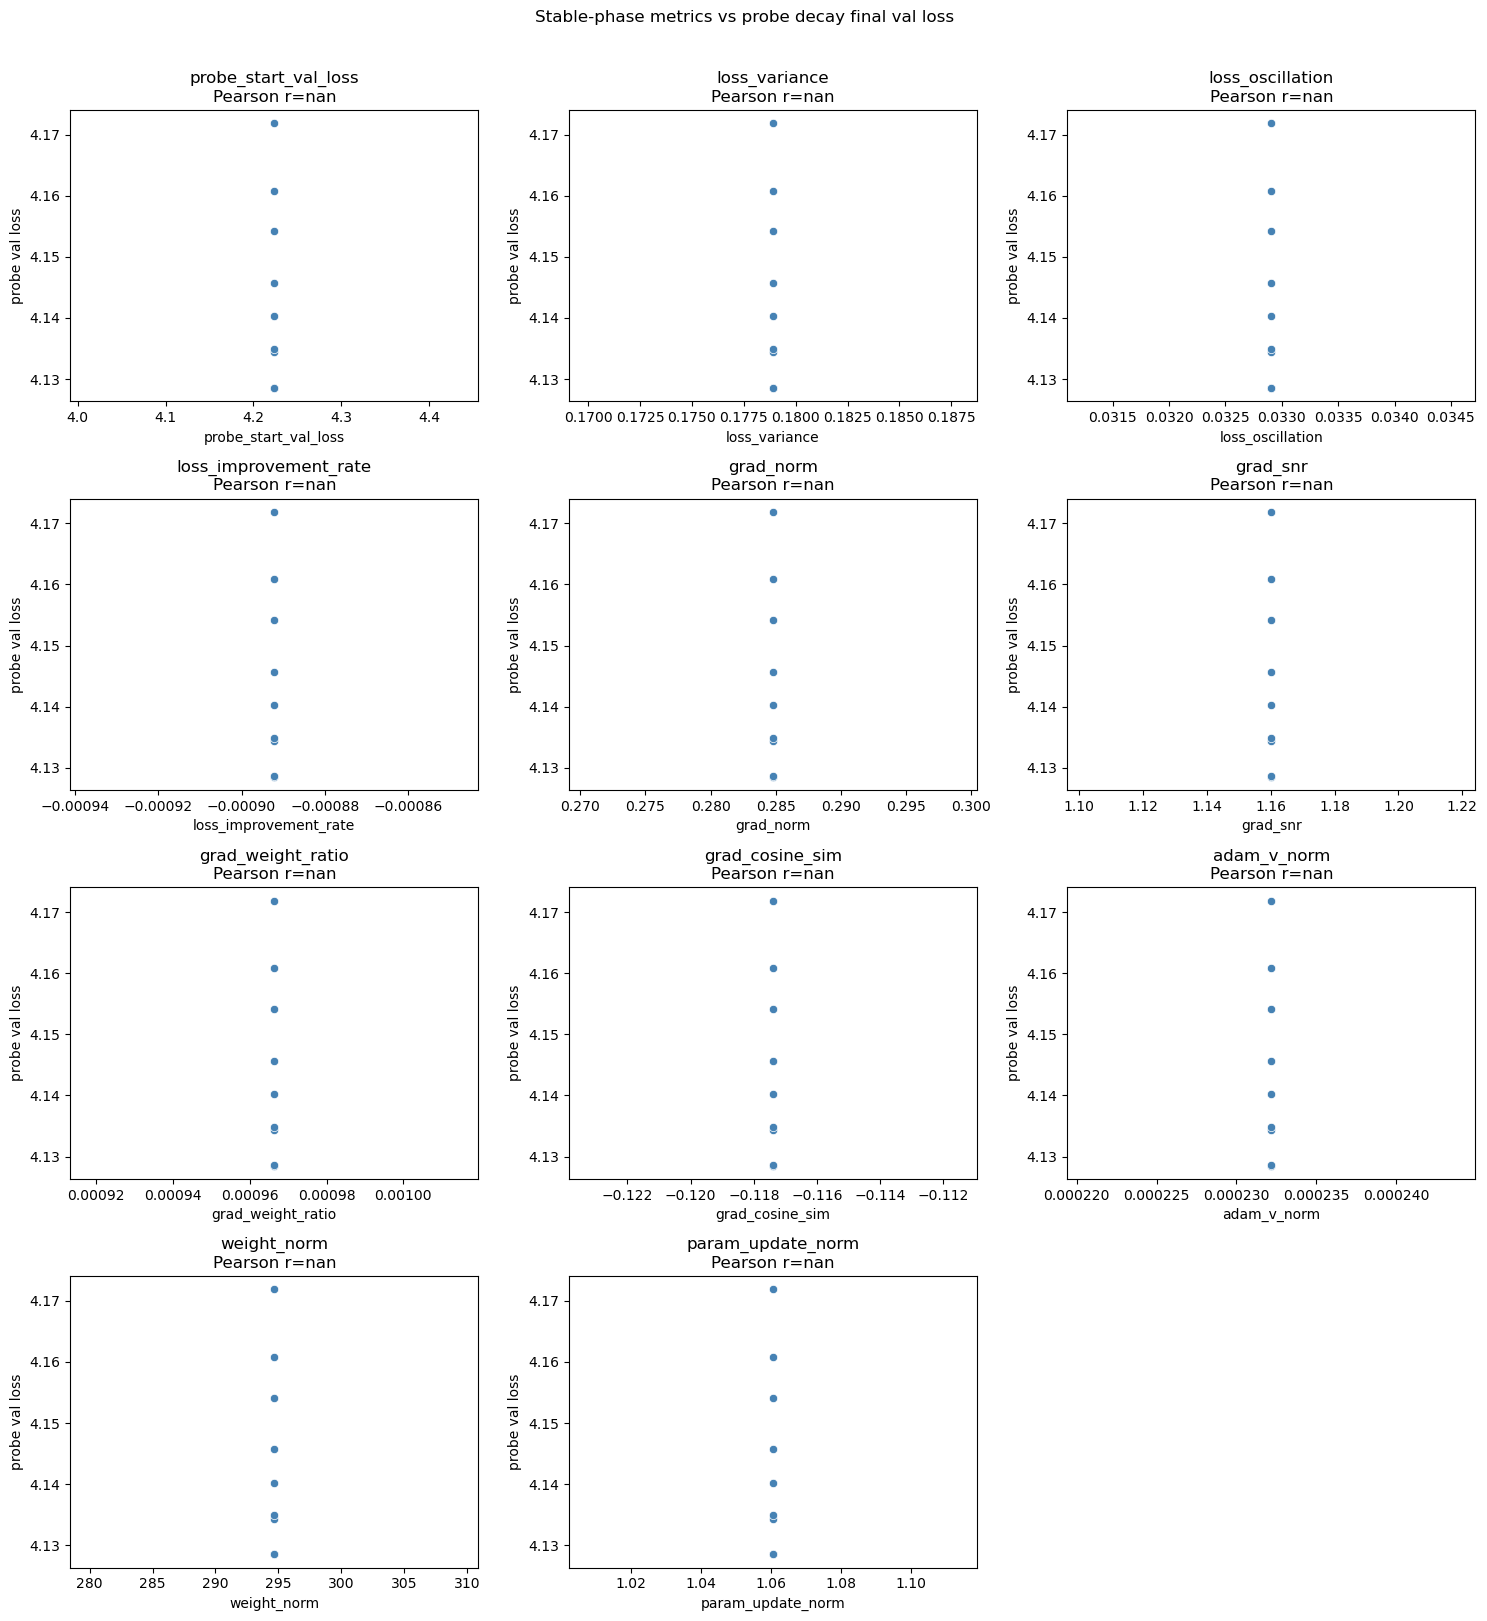

In [17]:
# Scatter plots: each metric vs probe final val loss
n = len(metric_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, metric_cols):
    x = sweep[col].values
    ax.scatter(x, y, color="steelblue", edgecolors="white", linewidth=0.5)
    # trend line
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() >= 2:
        m, b = np.polyfit(x[mask], y[mask], 1)
        xline = np.linspace(x[mask].min(), x[mask].max(), 100)
        ax.plot(xline, m * xline + b, color="tomato", linewidth=1.5)
    row = corr_df[corr_df["metric"] == col]
    r = row["pearson_r"].values[0] if len(row) else float("nan")
    ax.set_title(f"{col}\nPearson r={r:.2f}")
    ax.set_xlabel(col)
    ax.set_ylabel("probe val loss")

for ax in axes[len(metric_cols):]:
    ax.set_visible(False)

plt.suptitle("Stable-phase metrics vs probe decay final val loss", y=1.01)
plt.tight_layout()
plt.show()